Imports

In [1]:
import warnings
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from textwrap import wrap
from matplotlib.font_manager import FontProperties
import re
from scipy import stats
from matplotlib.lines import Line2D 

line_size=0.5
custom_params = {
    'axes.facecolor': 'white',
    'axes.edgecolor': 'black',
    'axes.grid': False,
    'axes.axisbelow': 'line',
    'axes.labelcolor': 'black',
    'figure.facecolor': 'white',
    "axes.spines.right": True, 
    "axes.spines.bottom": True,
    'xtick.direction': 'inout',
    'ytick.direction': 'in',
    'xtick.bottom': True,
    'xtick.minor.visible': False,
    'xtick.major.bottom':  True,
    'xtick.minor.bottom':  True,
    'xtick.major.pad':     7,     # distance to major tick label in points#
    'xtick.minor.pad':     3.4,     # distance to the minor tick label in points#
    'xtick.major.size':    10,
    'ytick.major.size':    4,
    'xtick.major.width':   line_size,
    'ytick.major.width':   line_size,
    'axes.linewidth': line_size,
    'xtick.minor.size':    2,
    'pdf.fonttype': 42}

sns.set_theme(style="ticks", rc=custom_params, font="Arial",font_scale=0.7)

enmax_palette = ["#648FFF", "#FE6100", "#785EF0", "#DC267F", "#FFB000"]
sns.set_palette(palette=enmax_palette)
warnings.filterwarnings("ignore")

Import data and create column combining line name and cycle

In [2]:
filename = "df_all.csv"
data = pd.read_csv(f'Figure_Data/{filename}')
df = pd.DataFrame(data)

# df = pd.read_csv('df_target_all.csv', index_col=0)
# df = pd.read_csv('df_all.csv', index_col=0)
df['line_name_cycle'] = df.apply(lambda x: f"{x['line_name_norep']}-c{x['cycle']}", axis = 1)

Get the mean titer for each single guide in DBTL0 and for the DBTL0 control. Then, create a dictionary for additive and fold change of titer for each individual guide. 

In [3]:
single_guide_titer = df.loc[
    (df['cycle'] == 0) & (~df['is_control']),
    ['target_1', 'isoprenol']
].groupby('target_1').mean()

control_titer = df.loc[
    (df['cycle'] == 0) & (df['is_control']),
    'isoprenol'
    ].mean()

titer_change_dict = {x:single_guide_titer.loc[x].values[0] - control_titer for x in single_guide_titer.index}
titer_fc_dict = {x:single_guide_titer.loc[x].values[0]/control_titer for x in single_guide_titer.index}
                 

Get the linear predicted titer change for each strain

In [4]:
def get_linear_titer_change(x, titer_change_dict, control_titer):
    n_grna = x['number_of_grna']
    grna_columns = [f'target_{i}' for i in range(1, n_grna)]
    linear_predicted_titer = control_titer+sum([titer_change_dict[x[c]] for c in grna_columns])
    return linear_predicted_titer

df['linear_predicted_titer'] = df.apply(lambda x: get_linear_titer_change(x, titer_change_dict=titer_change_dict, control_titer=control_titer), axis = 1)
mean_titer_comparison_df = df.loc[
    (
        (df['to_keep_improved']) &
        (df['cycle']>0)
    ),
    ['line_name_cycle', 'isoprenol', 'linear_predicted_titer', 'cycle', 'number_of_grna']
].groupby('line_name_cycle').mean()

mean_titer_comparison_df['Cycle'] = [f'Cycle {int(c)}' for c in mean_titer_comparison_df['cycle']]
mean_titer_comparison_df['delta_titer'] = mean_titer_comparison_df['isoprenol'] - mean_titer_comparison_df['linear_predicted_titer']


Plot linear prediction vs actual titer.

Text(0.5, 0, 'True isoprenol titer (mg/L)')

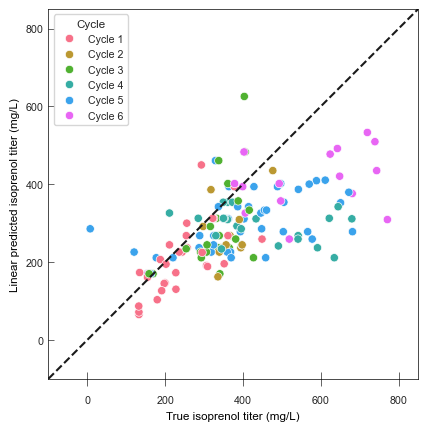

In [5]:
fig, ax = plt.subplots()
cycle_order = [f'Cycle {c}' for c in [1,2,3,4,5,6]]
sns.scatterplot(
    data = mean_titer_comparison_df,
    x = 'isoprenol',
    y = 'linear_predicted_titer',
    hue = 'Cycle',
    hue_order = cycle_order
)
ax.set_box_aspect(1)
ax.axline((0,0), slope = 1, c='k', linestyle = '--')
ax.set_ylim([-100, 850])
ax.set_xlim([-100, 850])
ax.set_ylabel('Linear predicted isoprenol titer (mg/L)')
ax.set_xlabel('True isoprenol titer (mg/L)')

Plot distribution of deviation from linearity for each cycle.

Text(0, 0.5, '(Measured titer)-(Linear predicted titer) (mg/L)')

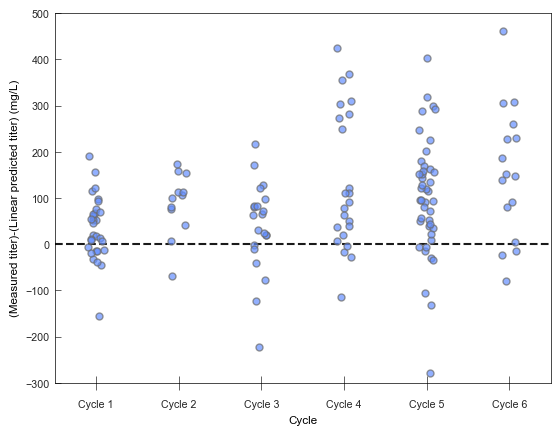

In [6]:
fig, ax = plt.subplots()
sns.stripplot(
    data = mean_titer_comparison_df,
    x = 'Cycle', 
    y = 'delta_titer',
    order = cycle_order,
    dodge = True,
    alpha= 0.7,
    linewidth=1
)
ax.axhline(0, c='k', linestyle = '--')
ax.set_ylim([-300, 500])
ax.set_ylabel('(Measured titer)-(Linear predicted titer) (mg/L)')

## Create heatmaps

First, get the identity of the sgRNA used in cycles 3-6. 

In [7]:
final_cycle_targets = []
for idx,row in df[df['cycle']>=3].iterrows():
    final_cycle_targets.extend(
        row[[f'target_{i}' for i in [1,2,3,4]]]
    )
final_cycle_targets = list(set(final_cycle_targets))
final_cycle_targets.remove(np.nan)
final_cycle_targets.sort()
print(final_cycle_targets)

['PP_0368', 'PP_0437', 'PP_0528', 'PP_0751', 'PP_0812', 'PP_0813', 'PP_0814', 'PP_0815', 'PP_1317', 'PP_1506', 'PP_1769', 'PP_2136', 'PP_4120', 'PP_4189', 'PP_4191', 'PP_4192']


Add one-hot encoded column for each individual sgRNA denoting its presence or absence in each strain.

In [8]:
for t in final_cycle_targets:
    mean_titer_comparison_df[t] = [int(t in line_name) for line_name in mean_titer_comparison_df.index]
mean_titer_comparison_df.sample(3)

,isoprenol,linear_predicted_titer,cycle,number_of_grna,Cycle,delta_titer,PP_0368,PP_0437,PP_0528,PP_0751,...,PP_0814,PP_0815,PP_1317,PP_1506,PP_1769,PP_2136,PP_4120,PP_4189,PP_4191,PP_4192
line_name_cycle,,,,,,,,,,,,,,,,,,,,,
PP_0812_PP_0814-c2,356.522667,244.105157,2.0,2.0,Cycle 2,112.417510,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
PP_0815_PP_2136-c5,577.881133,258.977800,5.0,2.0,Cycle 5,318.903333,0,0,0,0,...,0,1,0,0,0,1,0,0,0,0
PP_2137_PP_4011_PP_4120-c1,191.026400,126.296944,1.0,3.0,Cycle 1,64.729456,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0


Set heatmap colors

In [9]:
#Set colors
import matplotlib.colors as mcolors
colors = ['#2D67FF', 'white', '#FE6100']
custom_cmap = mcolors.LinearSegmentedColormap.from_list('CustomMap', colors)

Create a two shared heatmaps for each cycle, where one heatmap has the One-hot encoded strain identity and the other has the titer. 

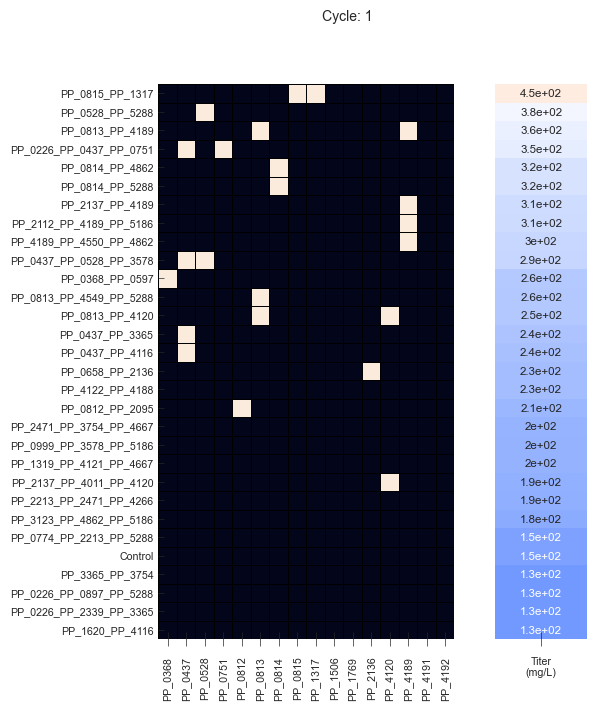

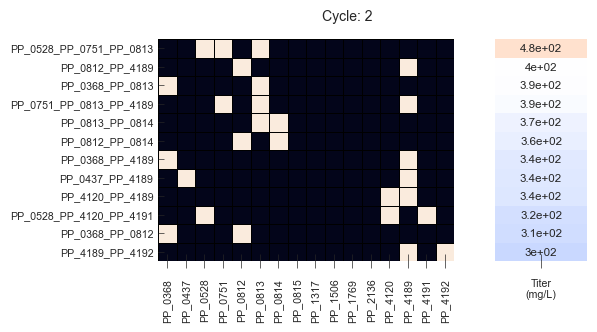

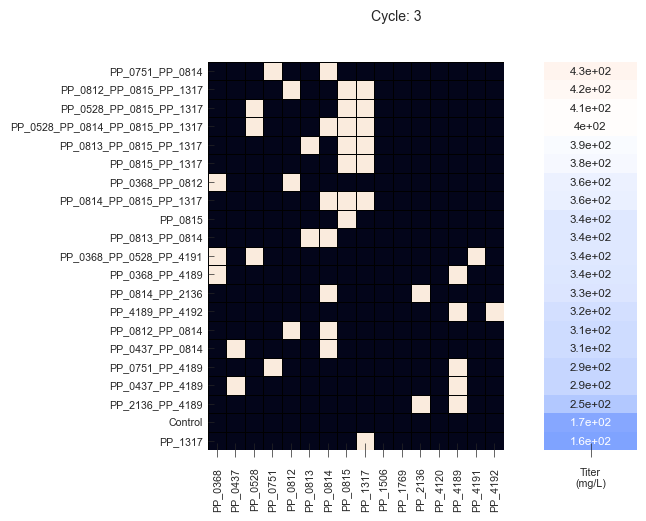

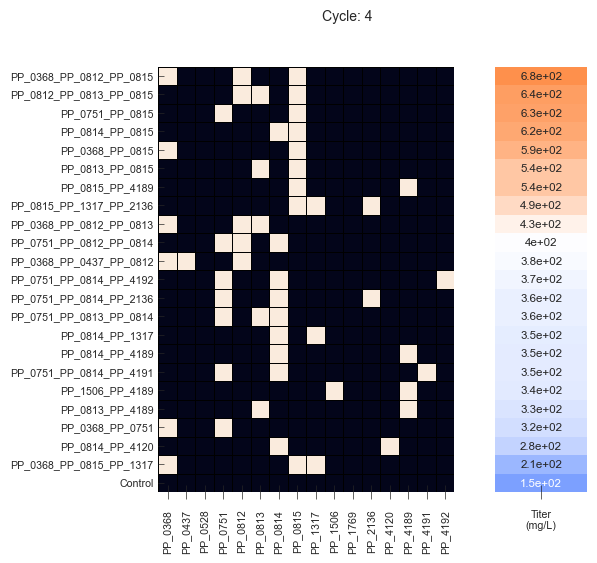

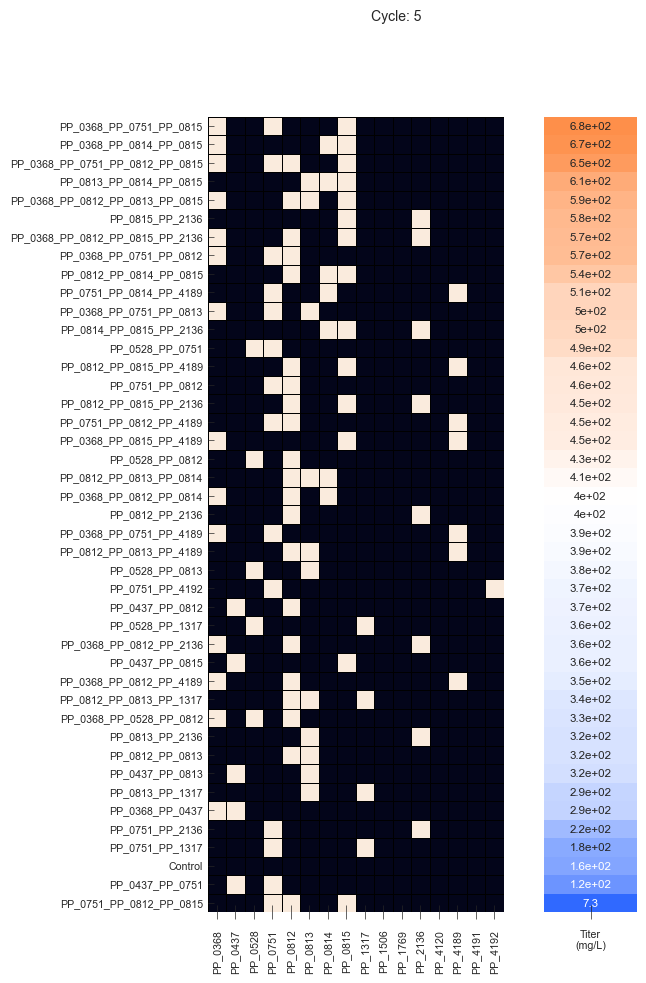

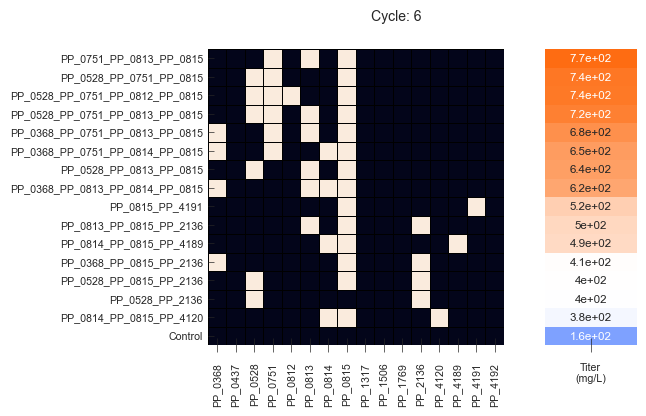

In [10]:
heatmap_cycles = [1,2,3,4,5,6]



for c in heatmap_cycles:
    sorted_df = mean_titer_comparison_df[mean_titer_comparison_df['cycle'] == c].sort_values('isoprenol', ascending = False)
    sorted_df['line_name'] = [x.split('-')[0] for x in sorted_df.index]
    sorted_df = sorted_df.set_index('line_name')

    fig, (ax1, ax2) = plt.subplots(
        ncols = 2,
        figsize = (6, sorted_df.shape[0]*0.25),
        gridspec_kw={'width_ratios': [4,1], 'wspace':0.02, 'bottom': 0.14},
    )
    sns.heatmap(
        sorted_df.loc[
            sorted_df['cycle']>0, final_cycle_targets
        ],
        ax = ax1,
        linewidths=0.5,
        square=True,
        linecolor='black',   
        cbar = False,
    )

    sns.heatmap(
        sorted_df.loc[sorted_df['cycle']>0, ['isoprenol']],
        yticklabels=[],
        cbar = False,
        ax = ax2,
        annot = True,
        vmin=0,
        vmax=800,
        cmap=custom_cmap, 
        xticklabels=['Titer\n(mg/L)']
    )
    ax2.set_ylabel('')
    ax1.set_ylabel('')
    fig.suptitle(f'Cycle: {c}')
    fname = f'Figure_Export/Fig_S7/epistasis_heatmap_cycle_{c}'
    fig.savefig(fname + '.pdf')
